In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import os
import json
import re
from utils import load_json
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from matplotlib import pyplot as plt
import seaborn as sns

In [16]:
def importance_to_binary_label(importance):
    importance = int(importance)
    if importance in [1,2]:
        return 1
    elif importance in [3]:
        return 2   
    elif importance in [4]:
        return 3
    else:
        raise ValueError("Invalid importance value")

def category_to_binary_label(category):
    if "LEVEL 1" in category:
        return 1
    elif "LEVEL 2" in category:
        return 2
    elif "LEVEL 3" in category:
        return 3
    else:
        raise ValueError(f"Invalid category value: {category}")

def get_df(output_dir = './results_levels/'):
    results = os.listdir(output_dir)

    data = []
    for result in results:
        #print(result)
        result_data = load_json(os.path.join(output_dir, result))
        item_id = result.split("_")[-1].split(".")[0]
        cot_facts_classification = category_to_binary_label(result_data["cot_facts"]['classification'])
        cot_law_classification = category_to_binary_label(result_data["cot_law"]['classification'])
        cot_facts_law_classification = category_to_binary_label(result_data["cot_facts_law"]['classification'])
        importance = int(result_data["importance"])
        ground_truth = importance_to_binary_label(importance)
        data.append(
            {
                "item_id": item_id,
                "facts": cot_facts_classification,
                "law": cot_law_classification,
                "facts_law": cot_facts_law_classification,
                "ground_truth": ground_truth,
                "importance": importance
            }
        )

    df = pd.DataFrame(data)
    return df


In [17]:
def get_metrics_binary(df, column):
    # Key Case vs. All
    # Ground truth: 1 for key case, 0 for not key case
    y_true = df['ground_truth']
    # Model predictions: 1 for key case, 0 for not key case
    y_pred = df[column]

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro")
    recall = recall_score(y_true, y_pred, average="macro")
    f1 = f1_score(y_true, y_pred, average="macro")

    # Classification report for additional insights
    rreport = classification_report(y_true, y_pred, target_names=["High", "Medium", "Low"], output_dict=True)
    report = classification_report(y_true, y_pred, target_names=["High", "Medium", "Low"])

    # Extracting micro and macro F1 scores
    micro_f1 = rreport["accuracy"]  # Micro F1 is equivalent to accuracy in binary classification
    macro_f1 = rreport["macro avg"]["f1-score"]

    # Presenting results
    metrics = {

        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Micro F1": micro_f1,
        "Macro F1": macro_f1,
    }
    return metrics, report


In [28]:
def get_confusion_matrix(df, column):
    cm = confusion_matrix(df['ground_truth'], df[column], normalize="true")
    return cm

def plot_confusion_matrix(df, column):
    cm = get_confusion_matrix(df, column)
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()


In [58]:
df = get_df()

In [59]:
df.head(3)

,item_id,facts,law,facts_law,ground_truth,importance
0,001-197098,3,1,2,1,1
1,001-218302,2,2,1,2,3
2,001-122893,2,1,1,1,2


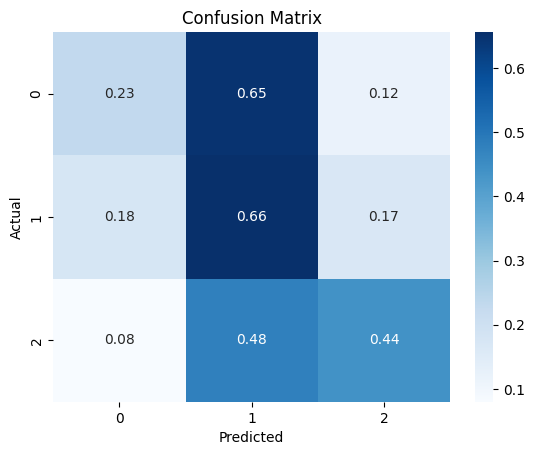

In [60]:
plot_confusion_matrix(df, "facts")
metrics, report = get_metrics_binary(df, "facts")

In [61]:
metrics

{'Accuracy': 0.39,
 'Precision': 0.4776830703593365,
 'Recall': 0.4426666666666667,
 'F1 Score': 0.3998837763543646,
 'Micro F1': 0.39,
 'Macro F1': 0.3998837763543646}

In [50]:
print(report)

              precision    recall  f1-score   support

        High       0.68      0.23      0.35       250
      Medium       0.30      0.66      0.41       125
         Low       0.29      0.39      0.33        54

    accuracy                           0.38       429
   macro avg       0.43      0.43      0.36       429
weighted avg       0.52      0.38      0.36       429



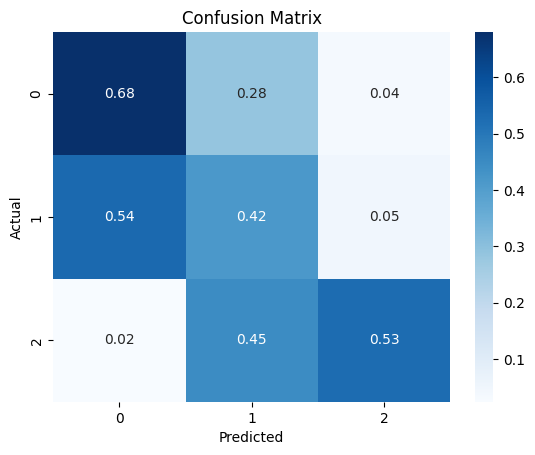

In [62]:
plot_confusion_matrix(df, "law")
metrics, report = get_metrics_binary(df, "law")

In [63]:
metrics

{'Accuracy': 0.576,
 'Precision': 0.6045503138147459,
 'Recall': 0.5413333333333333,
 'F1 Score': 0.5589198377358097,
 'Micro F1': 0.576,
 'Macro F1': 0.5589198377358097}

In [64]:
print(report)

              precision    recall  f1-score   support

        High       0.71      0.68      0.69       250
      Medium       0.29      0.42      0.34       125
         Low       0.81      0.53      0.64       125

    accuracy                           0.58       500
   macro avg       0.60      0.54      0.56       500
weighted avg       0.63      0.58      0.59       500



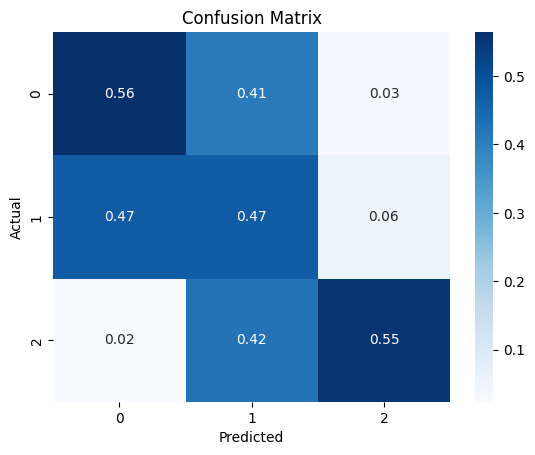

In [65]:
plot_confusion_matrix(df, "facts_law")
metrics, report = get_metrics_binary(df, "facts_law")

In [66]:
metrics

{'Accuracy': 0.538,
 'Precision': 0.6005358388574786,
 'Recall': 0.5293333333333333,
 'F1 Score': 0.5446868968743785,
 'Micro F1': 0.538,
 'Macro F1': 0.5446868968743785}

In [67]:
print(report)

              precision    recall  f1-score   support

        High       0.69      0.56      0.62       250
      Medium       0.28      0.47      0.35       125
         Low       0.83      0.55      0.66       125

    accuracy                           0.54       500
   macro avg       0.60      0.53      0.54       500
weighted avg       0.62      0.54      0.56       500



In [57]:
df[['facts', 'law', 'facts_law', 'ground_truth']].apply(pd.Series.value_counts)

,facts,law,facts_law,ground_truth
1,85,239,203,250
2,272,144,185,125
3,72,46,41,54


In [41]:
filtered_df = df.query('ground_truth == 0 and facts == 0 and law != 0 and facts_law != 0')
len(filtered_df)

0

In [42]:
filtered_df

,item_id,facts,law,facts_law,ground_truth,importance


In [43]:
filtered_df = df.query('ground_truth == 1 and facts == 1 and facts_law == 0')
len(filtered_df)

0

In [44]:
filtered_df['importance'].value_counts()

Series([], Name: count, dtype: int64)

In [45]:
filtered_df

,item_id,facts,law,facts_law,ground_truth,importance


In [23]:
filtered_df = df.query('ground_truth == 1 and facts == 0 and facts_law == 1')
len(filtered_df)

4

In [24]:
filtered_df['importance'].value_counts()

importance
3    4
Name: count, dtype: int64

In [25]:
s = {
    "cot_facts": {
        "explanation": "To determine whether this case qualifies as a key case or not, I need to analyze the facts for their broader implications on ECHR jurisprudence. The cases described involve individual applicants encountering delays and the eventual time-barring of criminal investigations in San Marino. The applicants were victims seeking justice for various grievances, including fraud, personal injury, and defamation, but the investigations did not progress effectively, leading to the conclusion of time-barring without substantial developments in law or principles. \n\nThe issues presented primarily revolve around procedural shortcomings, including delays in investigations and the consequent time-barring of criminal charges. However, these procedural matters do not address or establish new legal principles or offer significant interpretations concerning human rights law that would affect broader jurisprudence. The cases align more closely with existing case law regarding the right to an effective remedy and the reasonable time requirement under Article 6 of the ECHR but do not modify or create either existing or new interpretations of the Convention.\n\nOverall, the implications of this case seem confined to its immediate circumstances without significant contributions to the understanding or application of human rights law.",
        "classification": "NOT KEY CASE",
        "reasoning": "The case applies existing case law regarding procedural delays and time limitations without establishing new legal principles or significant implications beyond the immediate dispute."
    },
    "cot_law": {
        "explanation": "In analyzing the provided case law section, it is evident that the case involves multiple applicants challenging the outcomes related to their civil claims due to procedural issues in the San Marino judicial system. The Court examined the applicability of Article 6(1) of the European Convention on Human Rights, which guarantees access to court, especially concerning the determination of civil rights and obligations. The applicants argued that the excessive delays in the investigation led to the inability to pursue their civil claims effectively. \n\nThe Court ultimately determined that there was a violation of Article 6(1) for several applicants due to the inactivity of the judicial authorities, which significantly affected their ability to have their civil rights determined. This case contributes to the understanding of the right to access to court in conjunction with domestic legal systems and clarifies the responsibilities of judicial authorities in ensuring that victims can pursue their claims effectively within the established framework. \n\nWhile the case conveys procedural application of existing principles, the emphasis on the inactivity of authorities leading to the time-bar and the applicability of civil claims may guide future rulings, particularly in instances concerning the relationship between criminal procedures and access to civil rights. \n\nFurthermore, key distinctions in comparison to precedent cases are drawn, emphasizing the responsibilities of states under the Convention. The findings have broader implications, notably regarding the relationship between criminal and civil claims in human rights contexts, and potentially influencing how states manage investigations and uphold the rights of victims.",
        "classification": "KEY CASE",
        "reasoning": "The case clarifies crucial principles regarding the right to access a court (Article 6) under circumstances of judicial inactivity, creating significant implications for future jurisprudence and the responsibilities of domestic judicial systems."
    },
    "cot_facts_law": {
        "explanation": "To analyze the case, I must review the facts and law presented. The case involves multiple applicants whose civil claims were not properly adjudicated due to the inactivity of the authorities, leading to the dismissal of their claims because the criminal proceedings became time-barred. The applicants argued that this inaction violated their right of access to court under Article 6 of the European Convention of Human Rights (ECHR). \n\nI must assess whether this case contributes significantly to the development of ECHR jurisprudence. The court ultimately found a violation of Article 6 in terms of access to court for three of the applicants, specifically indicating that their inability to pursue their civil claims was primarily due to delays and inactivity attributable to the judicial authorities. The judgments reflect a nuanced interpretation of the interplay between criminal and civil proceedings, as well as the responsibilities of judicial authorities in ensuring timely access to justice.\n\nA critical aspect is that the court's decision is likely to reinforce the need for judicial accountability in maintaining procedural timelines and ensuring that victims have appropriate access to judicial remedies. This aspect points towards the case making a significant contribution to ECHR jurisprudence, particularly in clarifying the responsibilities of states related to the timeliness of judicial processes and the right to effective remedies for victims of criminal offenses.",
        "classification": "KEY CASE",
        "reasoning": "The case clarifies the burden on judicial authorities to ensure timely proceedings and highlights the connection between criminal inaction and civil claim access, contributing significantly to ECHR jurisprudence."
    },
    "importance": "3"
}

In [26]:
print(s['cot_facts']['reasoning'])

The case applies existing case law regarding procedural delays and time limitations without establishing new legal principles or significant implications beyond the immediate dispute.


In [27]:
print(s['cot_facts_law']['reasoning'])

The case clarifies the burden on judicial authorities to ensure timely proceedings and highlights the connection between criminal inaction and civil claim access, contributing significantly to ECHR jurisprudence.
